# Разведочный анализ с использованием pandas

Кольчурин Андрей Николавеич

студент физико-математического института,

направления радиофизика,

группы ФМ/О РФЗ-1-2022 НБ

Разведочный анализ данных (англ. exploratory data analysis, EDA) — анализ основных свойств данных, нахождение в них общих закономерностей, распределений и аномалий, построение начальных моделей, зачастую с использованием инструментов визуализации. Это понятие введено математиком Джоном Тьюки, который сформулировал цели такого анализа следующим образом:



*   максимальное «проникновение» в данные
*   выявление основных структур
*   выбор наиболее важных переменных
*   обнаружение отклонений и аномалий
*   проверка основных гипотез
*   разработка начальных моделей












Предварительная подготовка данных включает в себя очистку, отбор экземпляров, нормализацию, преобразование данных, выделение признаков, отбор признаков. Результатом предварительной обработки данных является конечный тренировочный набор.

Методы предварительной обработки данных:

*   Очистка данных используется для обнаружения, исправления или удаления ошибочных записей в наборе данных.
*   Нормализация данных используется для стандартизации диапазона значений независимых переменных или признаков данных (например, сведение к интервалам  [0,1]  или  [−1,+1] ).
*   Нормализация данных используется для стандартизации диапазона значений независимых переменных или признаков данных (например, сведение к интервалам  [0,1]  или  [−1,+1] ).
*   Выделение признаков используется для преобразования входных данных в набор признаков, которые они хорошо представляют.
*  Уплотнение данных используется для преобразования числовых данных в исправленный, упорядоченный и упрощённый вид. Это помогает уменьшить количество и/или размерность данных.





In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()  # устанавливаем seaborn по умолчанию для отрисовки графиков

Попробуем разобрать с набором данных "**Прогноз выживаемости пациентов сциррозом**"

Цирроз возникает из-за длительного повреждения печени, что приводит к обширным рубцовым образованиям, часто вызванным такими состояниями, как гепатит или хроническое употребление алкоголя. Предоставленные данные взяты из исследования первичного билиарного цирроза (ПБК) печени, проведённого в клинике Майо с 1974 по 1984 год.

Используя 17 клинических признаков можно прогнозировать выживаемость пациентов с циррозом печени. Условия выживаемости включают 0 = D (смерть), 1 = C (цензурировано), 2 = CL (цензурировано из-за пересадки печени).


In [ ]:
from google.colab import drive

drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
train = pd.read_csv('/content/drive/MyDrive/cirrhosis.csv')

In [ ]:
train.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


 **Описание полей**
*   ID - уникальный идентификатор пациента.

*  N_Days - количество дней между регистрацией и
более ранним сроком смерти, трансплантации или
анализа исследования.

*   Status - статус пациента ( D (смерть), C (цензурировано), CL (цензурировано из-за пересадки печени)).

*  Drug - тип препарата (D-пеницилламина или плацебо).

*   Age - возраст.

*   Sex - пол: M (мужской), F (женский).

*   Ascites - наличие асцитов ( N (Нет) или Y (Да)).

*  Hepatomegaly - наличие гепатомегалии ( N (Нет) или Y (Да)).

*   Spiders - присутствие пауков ( N (Нет) или Y (Да)).

*   Edema - Наличие отёка ( N (отёка нет и нет диуретической терапии при отёке), S (отёк присутствует без диуретиков или отек, проходящий диуретиками), или Y (отёк несмотря на диуретическую терапию)).

*   Bilirubin - Сывороточный билирубин.

*   Cholesterol - Сывороточный холестерин.

*   Albumin - Альбумин.

*   Copper - моча, медь.

*   Alk_Phos - щелочная фосфатаза.

*   SGOT

*   Tryglicerides - триглицериды.


*   Platelets - Тромбоциты на куб.

*   Prothrombin - протромбиновое время.

*   Stage - Гистологическая стадия заболевания (1, 2, 3 или 4).






Продолжаем исследовать обучающий набор данных. Посмотрим на общую статистику числовых данных.

In [ ]:
train.describe()

,ID,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
count,418.000000,418.000000,418.000000,418.000000,284.000000,418.000000,310.000000,312.000000,312.000000,282.000000,407.000000,416.000000,412.000000
mean,209.500000,1917.782297,18533.351675,3.220813,369.510563,3.497440,97.648387,1982.655769,122.556346,124.702128,257.024570,10.731731,3.024272
std,120.810458,1104.672992,3815.845055,4.407506,231.944545,0.424972,85.613920,2140.388824,56.699525,65.148639,98.325585,1.022000,0.882042
min,1.000000,41.000000,9598.000000,0.300000,120.000000,1.960000,4.000000,289.000000,26.350000,33.000000,62.000000,9.000000,1.000000
25%,105.250000,1092.750000,15644.500000,0.800000,249.500000,3.242500,41.250000,871.500000,80.600000,84.250000,188.500000,10.000000,2.000000
50%,209.500000,1730.000000,18628.000000,1.400000,309.500000,3.530000,73.000000,1259.000000,114.700000,108.000000,251.000000,10.600000,3.000000
75%,313.750000,2613.500000,21272.500000,3.400000,400.000000,3.770000,123.000000,1980.000000,151.900000,151.000000,318.000000,11.100000,4.000000
max,418.000000,4795.000000,28650.000000,28.000000,1775.000000,4.640000,588.000000,13862.400000,457.250000,598.000000,721.000000,18.000000,4.000000


Вспомните, что обозначают эти результаты? Какие предварительные выводы можно сделать из этих данных?

Проанализируем нечисловые данные.

In [ ]:
train.describe(include=['O'])

,Status,Drug,Sex,Ascites,Hepatomegaly,Spiders,Edema
count,418,312,418,312,312,312,418
unique,3,2,2,2,2,2,3
top,C,D-penicillamine,F,N,Y,N,N
freq,232,158,374,288,160,222,354


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    object 
 3   Drug           312 non-null    object 
 4   Age            418 non-null    int64  
 5   Sex            418 non-null    object 
 6   Ascites        312 non-null    object 
 7   Hepatomegaly   312 non-null    object 
 8   Spiders        312 non-null    object 
 9   Edema          418 non-null    object 
 10  Bilirubin      418 non-null    float64
 11  Cholesterol    284 non-null    float64
 12  Albumin        418 non-null    float64
 13  Copper         310 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  282 non-null    float64
 17  Platelets      407 non-null    float64
 18  Prothrombi

Можно сделать вывод.

Четверть пациентов имеет неполный набор клинических и лабораторных данных.

In [ ]:

categorical_features = train.select_dtypes(include=['object', 'category', 'bool']).columns
print("Категориальные признаки:")
print(categorical_features.tolist())
print(f"\nВсего категориальных признаков: {len(categorical_features)}")

Категориальные признаки:
['Status', 'Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema']

Всего категориальных признаков: 7


In [ ]:
train.isnull().sum()

,0
ID,0
N_Days,0
Status,0
Drug,106
Age,0
Sex,0
Ascites,106
Hepatomegaly,106
Spiders,106
Edema,0


По предыдущим данным модно сказать что, 9 столбцов с пропусками >25%.

Липидный профиль (холестерин, триглицериды) отсутствует у ~32% пациентов.
Медь отсутствует у ~26% пациентов.

Ровно 106 пропусков в 6 столбцах — это одни и те же пациенты.
Вероятно, 25.4% пациенты, которые не прошли полное клиническое обследование.

Уберем пациентов с системными пропусками.

In [ ]:
train.dropna(subset=['Drug', 'Ascites', 'Hepatomegaly', 'Spiders', 'Alk_Phos', 'SGOT'], inplace=True)
train.isnull().sum()

,0
ID,0
N_Days,0
Status,0
Drug,0
Age,0
Sex,0
Ascites,0
Hepatomegaly,0
Spiders,0
Edema,0


In [ ]:
train.Cholesterol.describe()

,Cholesterol
count,284.000000
mean,369.510563
std,231.944545
min,120.000000
25%,249.500000
50%,309.500000
75%,400.000000
max,1775.000000


Оставишиеся пропуски заполним средними значенями

In [ ]:
train.Cholesterol = train.Cholesterol.fillna(train.Cholesterol.median())
train.Tryglicerides = train.Tryglicerides.fillna(train.Tryglicerides.median())
train.Copper = train.Copper.fillna(train.Copper.median())
train.Platelets = train.Platelets.fillna(train.Platelets.median())

In [ ]:
train.isnull().sum()

,0
ID,0
N_Days,0
Status,0
Drug,0
Age,0
Sex,0
Ascites,0
Hepatomegaly,0
Spiders,0
Edema,0


## **Кодирование категориальных признаков**

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder()
train[['Sex', 'Status', 'Drug', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema']] = enc.fit_transform(train[['Sex', 'Status', 'Drug', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema']])
train.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,2.0,0.0,21464,0.0,1.0,1.0,1.0,2.0,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,0.0,0.0,20617,0.0,0.0,1.0,1.0,0.0,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,2.0,0.0,25594,1.0,0.0,0.0,0.0,1.0,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,2.0,0.0,19994,0.0,0.0,1.0,1.0,1.0,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,1.0,1.0,13918,0.0,0.0,1.0,1.0,0.0,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


# **Визуализация**

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 17.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 20.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 9.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


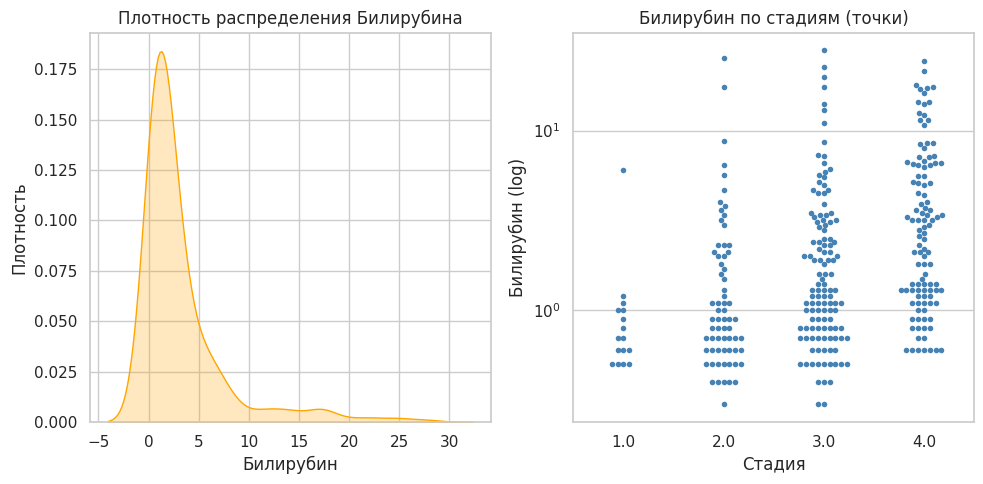

In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

fig, axes = plt.subplots(1, 2)

# KDE plot (плавная кривая распределения)
sns.kdeplot(data=train, x='Bilirubin', ax=axes[0], fill=True, color='orange')
axes[0].set_title('Плотность распределения Билирубина')
axes[0].set_xlabel('Билирубин')
axes[0].set_ylabel('Плотность')

# Swarm plot (точки без наложения)
sns.swarmplot(x='Stage', y='Bilirubin', data=train, ax=axes[1], size=4, color='steelblue')
axes[1].set_yscale('log')
axes[1].set_title('Билирубин по стадиям (точки)')
axes[1].set_xlabel('Стадия')
axes[1].set_ylabel('Билирубин (log)')

plt.tight_layout()
plt.show()

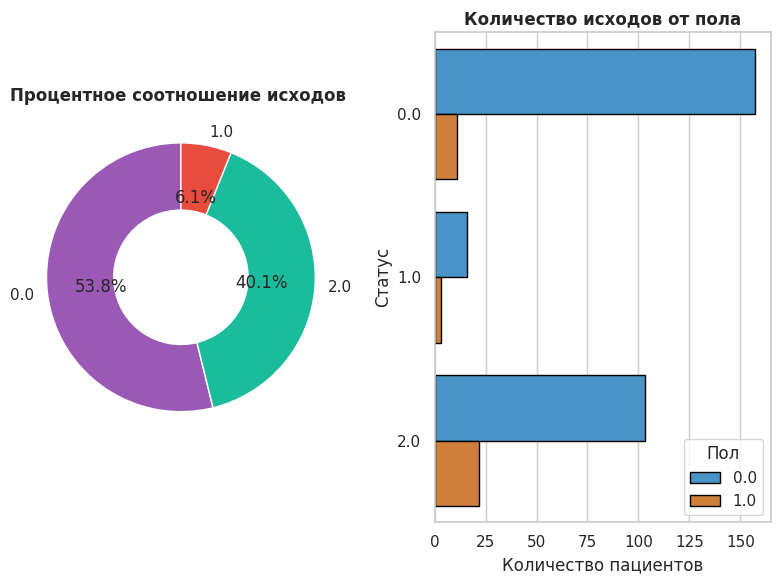

In [ ]:

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (14, 6)

fig, axes = plt.subplots(1, 2, figsize=(8, 6))

# Donut chart вместо pie
colors = ['#9b59b6', '#1abc9c', '#e74c3c']
wedges, texts, autotexts = axes[0].pie(train['Status'].value_counts(),
                                        labels=train['Status'].value_counts().index,
                                        autopct='%1.1f%%',
                                        colors=colors,
                                        startangle=90,
                                        wedgeprops=dict(width=0.5, edgecolor='white'))
axes[0].set_title('Процентное соотношение исходов ', fontsize=12, fontweight='bold')

# Horizontal bar chart вместо countplot
sns.countplot(y='Status', hue='Sex', data=train, ax=axes[1], palette=['#3498db', '#e67e22'], edgecolor='black')
axes[1].set_title('Количество исходов от пола', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Количество пациентов')
axes[1].set_ylabel('Статус')
axes[1].legend(title='Пол')

plt.tight_layout()
plt.show()

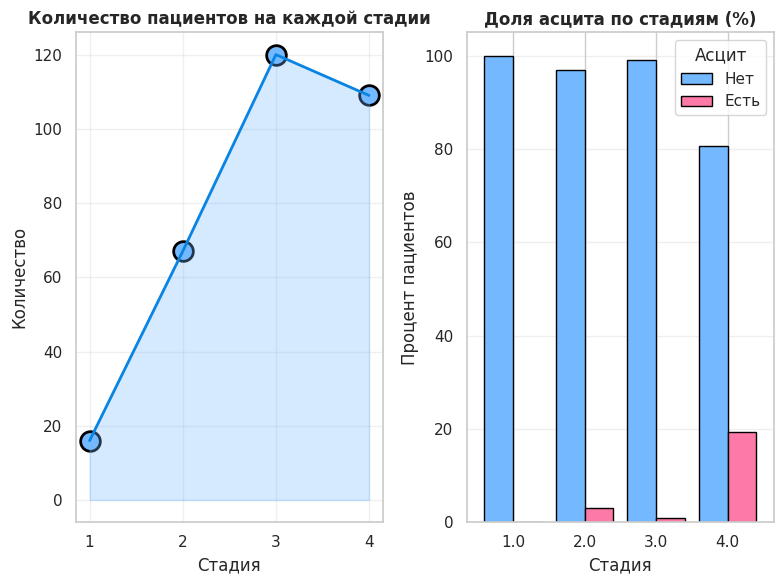

In [ ]:

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (14, 6)

fig, axes = plt.subplots(1, 2, figsize=(8, 6))

# Point plot вместо countplot
stage_counts = train['Stage'].value_counts().sort_index()
axes[0].scatter(stage_counts.index, stage_counts.values, s=200, color='#74b9ff', edgecolor='black', linewidth=2)
axes[0].plot(stage_counts.index, stage_counts.values, color='#0984e3', linewidth=2)
axes[0].fill_between(stage_counts.index, stage_counts.values, alpha=0.3, color='#74b9ff')
axes[0].set_title('Количество пациентов на каждой стадии', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Стадия')
axes[0].set_ylabel('Количество')
axes[0].grid(alpha=0.3)

# Grouped bar вместо stacked
stage_ascites = pd.crosstab(train['Stage'], train['Ascites'], normalize='index') * 100
stage_ascites.plot(kind='bar', ax=axes[1], color=['#74b9ff', '#fd79a8'], edgecolor='black', width=0.8)
axes[1].set_title('Доля асцита по стадиям (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Стадия')
axes[1].set_ylabel('Процент пациентов')
axes[1].legend(title='Асцит', labels=['Нет', 'Есть'])
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_292/924716994.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=train, x='Status', y='Age_years', ax=axes[0], palette=['#ff6b6b', '#4ecdc4', '#45b7d1'])
/tmp/ipykernel_292/924716994.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=train, x='Status', y='Age_years', ax=axes[1], palette=['#ff6b6b', '#4ecdc4', '#45b7d1'],


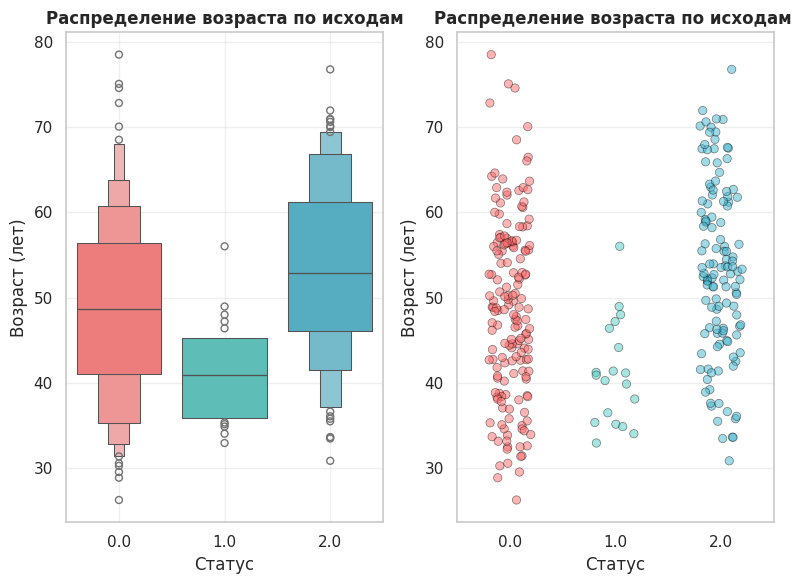

In [ ]:

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (12, 6)

# Создаём признак возраста в годах
train['Age_years'] = train['Age'] / 365

fig, axes = plt.subplots(1, 2, figsize=(8, 6))

# Boxen plot (letter-value plot) вместо KDE
sns.boxenplot(data=train, x='Status', y='Age_years', ax=axes[0], palette=['#ff6b6b', '#4ecdc4', '#45b7d1'])
axes[0].set_title('Распределение возраста по исходам', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Статус')
axes[0].set_ylabel('Возраст (лет)')
axes[0].grid(alpha=0.3)

# Strip plot с jitter
sns.stripplot(data=train, x='Status', y='Age_years', ax=axes[1], palette=['#ff6b6b', '#4ecdc4', '#45b7d1'],
              size=6, alpha=0.5, jitter=0.2, edgecolor='black', linewidth=0.5)
axes[1].set_title('Распределение возраста по исходам ', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Статус')
axes[1].set_ylabel('Возраст (лет)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

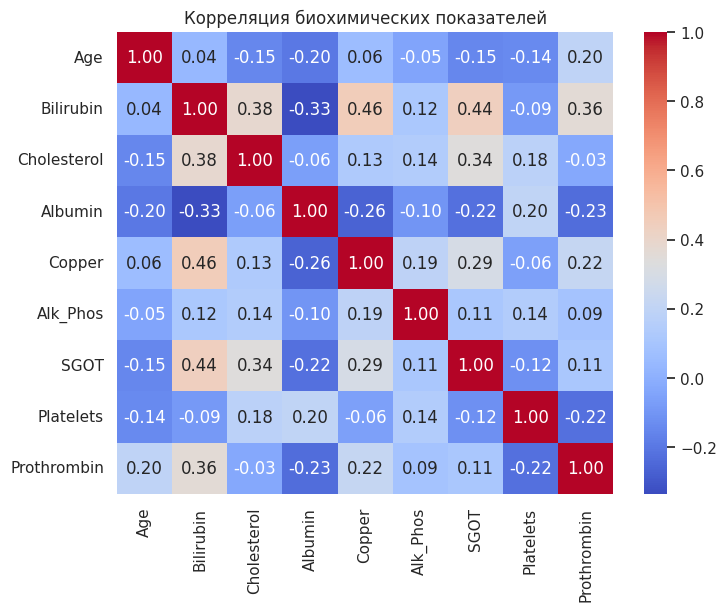

In [ ]:
#Тепловая карта корреляций
plt.figure(figsize=(8, 6))
numeric_cols = ['Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Platelets', 'Prothrombin']
sns.heatmap(train[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Корреляция биохимических показателей')
plt.show()


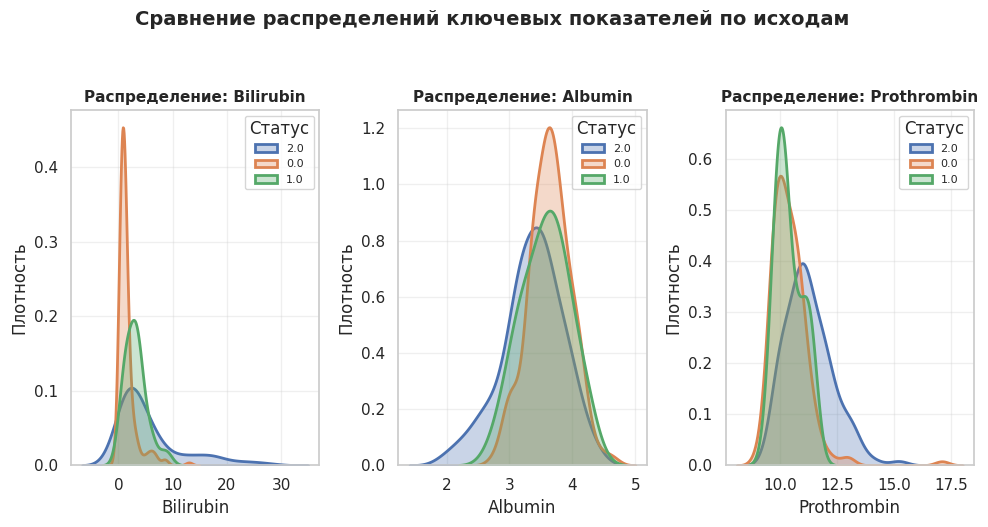

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (15, 5)

vars_to_plot = ['Bilirubin', 'Albumin', 'Prothrombin']
fig, axes = plt.subplots(1, 3, figsize=(10, 5))

for idx, var in enumerate(vars_to_plot):
    # Гистограмма + KDE для каждого признака, раскрашенная по статусу
    for status in train['Status'].unique():
        subset = train[train['Status'] == status]
        sns.kdeplot(data=subset, x=var, ax=axes[idx], fill=True, alpha=0.3, label=status, linewidth=2)

    axes[idx].set_title(f'Распределение: {var}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(var)
    axes[idx].set_ylabel('Плотность')
    axes[idx].legend(title='Статус', fontsize=8)
    axes[idx].grid(alpha=0.3)

plt.suptitle('Сравнение распределений ключевых показателей по исходам', y=1.05, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()